In [1]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import os

In [15]:
# Paths
subject = "sub-racsleep31"
subject_dir = f"/orcd/data/ldlewis/001/om/hf303/for_ore/{subject}/eeg/"
behavior_mat = "/orcd/data/ldlewis/001/om/hf303/pet_eeg_fmri/racsleep31/behav/racsleep31_run01_buttonpresses_clean.mat"

# Load EEG
eeg_files = [f for f in os.listdir(subject_dir) if f.startswith('c') and f.endswith('.mat')]
if len(eeg_files) == 0:
    raise FileNotFoundError("No EEG time series file found.")
eeg_mat_path = os.path.join(subject_dir, eeg_files[0])
eeg_mat = sio.loadmat(eeg_mat_path)
print("EEG MAT keys:", eeg_mat.keys())


if 'ch' in eeg_mat:
    eeg_data = np.squeeze(eeg_mat['ch'])
else:
    #last non-meta value
    candidates = {k: v for k, v in eeg_mat.items() if not k.startswith('__')}
    #the largest 1D array
    eeg_data = max(candidates.values(), key=lambda a: np.size(a))
    eeg_data = np.squeeze(eeg_data)

print("EEG shape (samples):", eeg_data.shape)

#button presses
mat = sio.loadmat(behavior_mat)
press_times = np.squeeze(mat['buttonpresses_clean']).flatten()
print("Number of button presses:", len(press_times))

# load spectrogram 
spec_path = os.path.join(subject_dir, "spectrogram.mat")
spec_mat = sio.loadmat(spec_path)
print("Spectrogram keys:", spec_mat.keys())

# from output keys
Sxx_raw = np.squeeze(spec_mat['eeg_spec'])   # currently time x freq or freq x time
spec_times = np.squeeze(spec_mat['eeg_t'])   
spec_freqs = np.squeeze(spec_mat['eeg_f'])   
print("Raw Sxx shape:", Sxx_raw.shape)
print("spec_times shape:", spec_times.shape, "spec_freqs shape:", spec_freqs.shape)






EEG MAT keys: dict_keys(['__header__', '__version__', '__globals__', 'cleaned'])
EEG shape (samples): (845600,)
Number of button presses: 987
Spectrogram keys: dict_keys(['__header__', '__version__', '__globals__', 'eeg_spec', 'eeg_t', 'eeg_f'])
Raw Sxx shape: (20434, 410)
spec_times shape: (20434,) spec_freqs shape: (410,)


In [16]:
# making sure spectrogram is freq x time 
#expect Sxx_freqtime shape: (n_freqs, n_times)
if Sxx_raw.shape == (spec_times.size, spec_freqs.size):
    # current layout is time x freq -> transpose
    Sxx = Sxx_raw.T
    print("Transposed Sxx to shape (freq x time):", Sxx.shape)
elif Sxx_raw.shape == (spec_freqs.size, spec_times.size):
    Sxx = Sxx_raw
    print("Sxx already freq x time:", Sxx.shape)
else:
    # trying to infershapes by matching dims
    if Sxx_raw.shape[0] == spec_freqs.size or Sxx_raw.shape[1] == spec_freqs.size:
        if Sxx_raw.shape[0] == spec_freqs.size:
            Sxx = Sxx_raw
        else:
            Sxx = Sxx_raw.T
        print("Inferred Sxx shape (freq x time):", Sxx.shape)
    else:
        raise ValueError(f"Can't infer orientation of Sxx (shape {Sxx_raw.shape}) relative to freqs {spec_freqs.shape} and times {spec_times.shape}")

# Convert to dB safely 
Sxx_db = 10 * np.log10(Sxx + 1e-12)

# Estimate EEG sampling rate 
# If spectrogram times correspond to seconds across the same recording duration as EEG,
# estimate as  fs_eeg = n_samples_eeg / duration_seconds. 
if spec_times.size > 1:
    duration = spec_times[-1] - spec_times[0]
    if duration > 0:
        fs_eeg = eeg_data.size / duration
        print(f"Estimated EEG sampling rate from spectrogram times: {fs_eeg:.2f} Hz")
    else:
        fs_eeg = 500.0
        print("spec_times has zero duration: falling back to fs=500 Hz")
else:
    fs_eeg = 500.0
    print("spec_times not valid: falling back to fs=500 Hz")

Transposed Sxx to shape (freq x time): (410, 20434)
Estimated EEG sampling rate from spectrogram times: 206.92 Hz


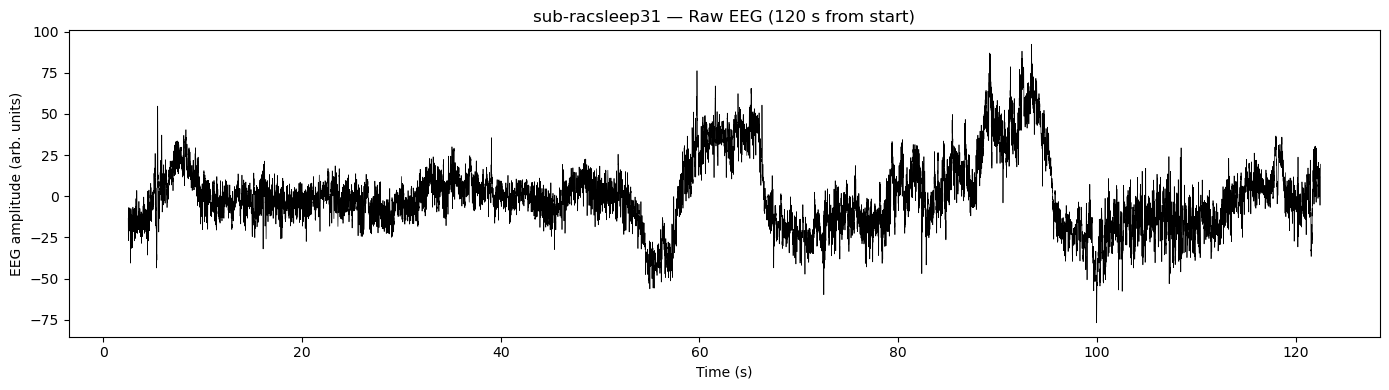

In [17]:
# Building eeg_time in seconds, aligned so that eeg_time[0] corresponds to spec_times[0]
# I am assuming EEG recording and spectrogram share same time reference
eeg_time = np.arange(eeg_data.size) / fs_eeg
# align start to spectrogram start 
eeg_time = eeg_time + spec_times[0]

#raw EEG plot (first 120s from spectrogram start) 
seconds_to_plot = 120
end_time = spec_times[0] + seconds_to_plot
mask_eeg = (eeg_time >= spec_times[0]) & (eeg_time <= end_time)
plt.figure(figsize=(14, 4))
plt.plot(eeg_time[mask_eeg], eeg_data[mask_eeg], color='black', linewidth=0.5)
plt.title(f"{subject} — Raw EEG ({seconds_to_plot} s from start)")
plt.xlabel("Time (s)")
plt.ylabel("EEG amplitude (arb. units)")
plt.tight_layout()
plt.show()

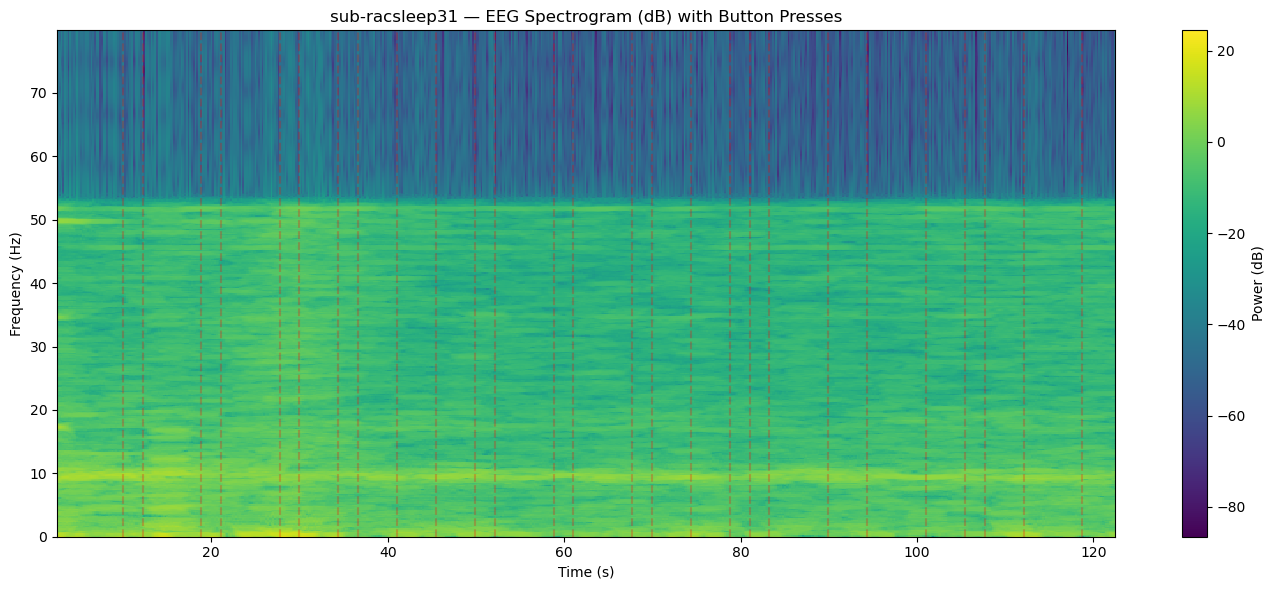

In [18]:
# Spectrogram (dB) with button presses 
plt.figure(figsize=(14, 6))
# extent: [t0, t1, f0, f1]
plt.imshow(Sxx_db, aspect='auto', origin='lower',
           extent=[spec_times[0], spec_times[-1], spec_freqs[0], spec_freqs[-1]],
           interpolation='nearest')
plt.colorbar(label='Power (dB)')
plt.title(f"{subject} — EEG Spectrogram (dB) with Button Presses")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
# overlay presses
for t in press_times:
    plt.axvline(x=t, color='red', linestyle='--', alpha=0.25)
plt.xlim(spec_times[0], spec_times[0] + seconds_to_plot)  # zoom to first 120s by default ( will change as needed)
plt.tight_layout()
plt.show()


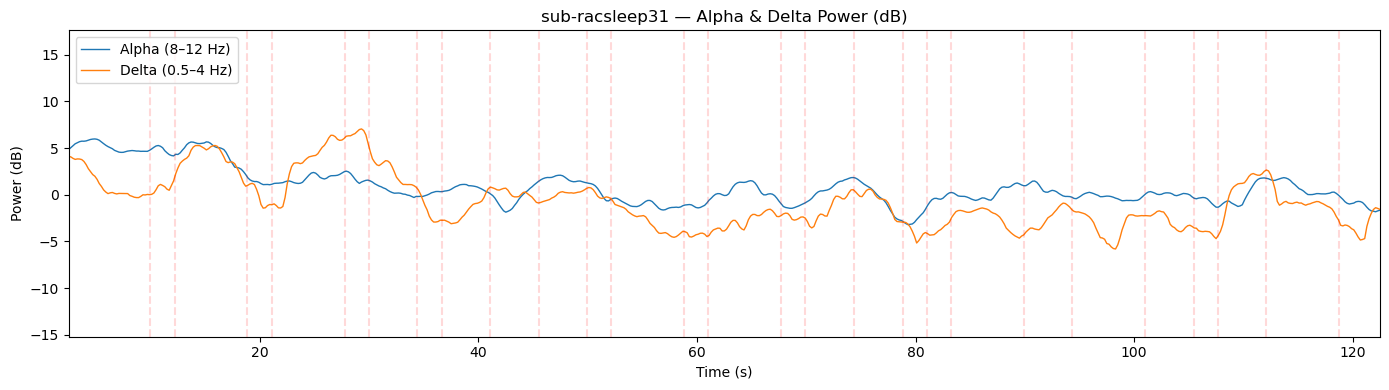

In [19]:
# alpha and delta band power from spectrogram (freq x time) 
alpha_mask = (spec_freqs >= 8) & (spec_freqs <= 12)
delta_mask = (spec_freqs >= 0.5) & (spec_freqs <= 4)

if alpha_mask.sum() == 0 or delta_mask.sum() == 0:
    print("Warning: alpha or delta masks empty — check freq vector.")
alpha_power = np.mean(Sxx[alpha_mask, :], axis=0)   # shape: (n_times,)
delta_power = np.mean(Sxx[delta_mask, :], axis=0)

alpha_db = 10 * np.log10(alpha_power + 1e-12)
delta_db = 10 * np.log10(delta_power + 1e-12)

# plot alpha & delta over spectrogram time axis 
plt.figure(figsize=(14, 4))
plt.plot(spec_times, alpha_db, label='Alpha (8–12 Hz)', linewidth=1)
plt.plot(spec_times, delta_db, label='Delta (0.5–4 Hz)', linewidth=1)
for t in press_times:
    plt.axvline(x=t, color='red', linestyle='--', alpha=0.15)
plt.xlim(spec_times[0], spec_times[0] + seconds_to_plot)  # zoom to first 120s
plt.xlabel("Time (s)")
plt.ylabel("Power (dB)")
plt.title(f"{subject} — Alpha & Delta Power (dB)")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# zoom function for time windows (seconds) 
def plot_zoom(t0, t1, channel_plot_eeg=True, show_spec=True):
    # raw EEG zoom
    mask_eeg = (eeg_time >= t0) & (eeg_time <= t1)
    if channel_plot_eeg:
        plt.figure(figsize=(12, 3))
        plt.plot(eeg_time[mask_eeg], eeg_data[mask_eeg], color='k', linewidth=0.6)
        plt.title(f"EEG raw {t0:.1f}s to {t1:.1f}s")
        for t in press_times:
            if t0 <= t <= t1:
                plt.axvline(x=t, color='red', alpha=0.3)
        plt.xlabel("Time (s)")
        plt.tight_layout()
        plt.show()
    # spectrogram zoom
    if show_spec:
        # find column indices in spectrogram corresponding to t0..t1
        idx0 = np.searchsorted(spec_times, t0, side='left')
        idx1 = np.searchsorted(spec_times, t1, side='right')
        plt.figure(figsize=(12, 4))
        im = plt.imshow(Sxx_db[:, idx0:idx1], aspect='auto', origin='lower',
                        extent=[spec_times[idx0], spec_times[idx1-1], spec_freqs[0], spec_freqs[-1]],
                        interpolation='nearest')
        plt.colorbar(im, label='Power (dB)')
        for t in press_times:
            if t0 <= t <= t1:
                plt.axvline(x=t, color='red', alpha=0.4)
        plt.title(f"Spectrogram {t0:.1f}s to {t1:.1f}s")
        plt.xlabel("Time (s)")
        plt.ylabel("Frequency (Hz)")
        plt.tight_layout()
        plt.show()


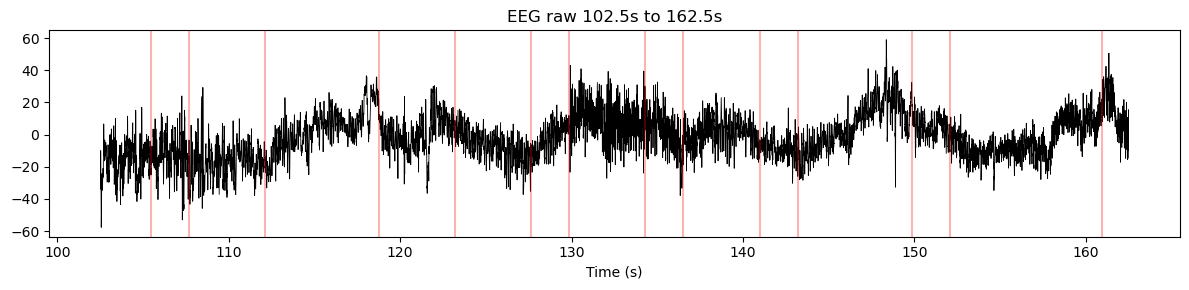

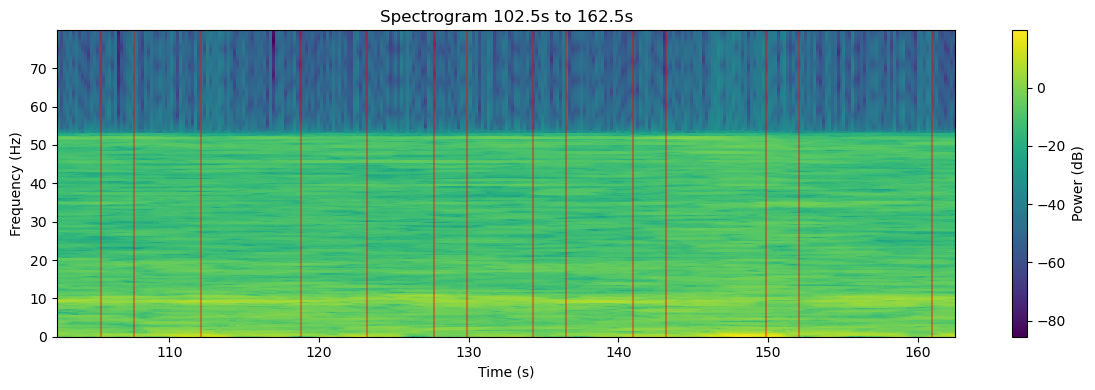

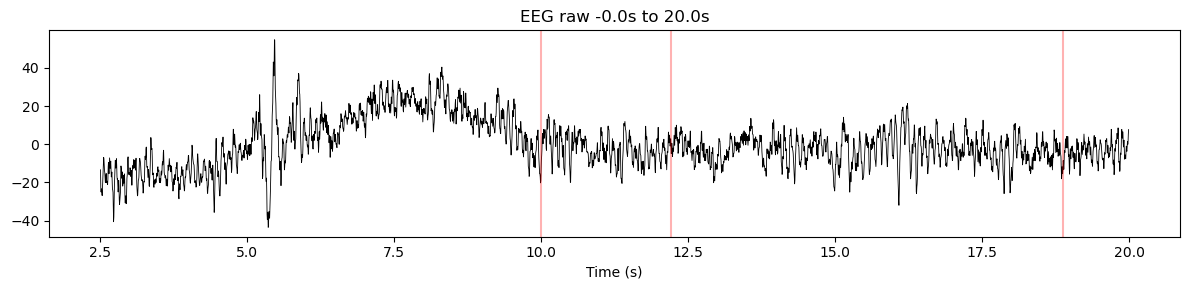

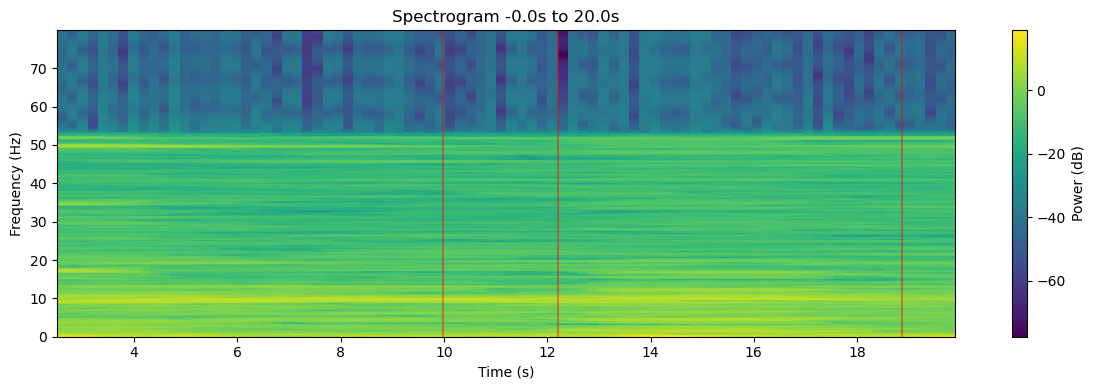

In [21]:
# zoom to 100s - 160s (1 minute)
plot_zoom(spec_times[0] + 100, spec_times[0] + 160)
#zoom ±10s around the first button press:
if len(press_times) > 0:
    t_first = press_times[0]
    plot_zoom(t_first - 10, t_first + 10)